# Expected Goals — Baseline

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.data.split_data import train_test_split_by_match
from src.visualization.plot_xg_surface import plot_xg_surface
from src.visualization.plot_calibration import plot_calibration

In [14]:
df = pd.read_csv("../../data/processed/shots.csv")

df.head()

,match_id,period,minute,second,team,player,x,y,goal,body_part,...,first_time,aerial_won,one_on_one,deflected,open_goal,saved_off_target,redirect,saved_to_post,follows_dribble,statsbomb_xg
0,3754300,1,12,14,Watford,Troy Deeney,108.9,40.6,0,Right Foot,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085717
1,3754300,1,12,52,Watford,Troy Deeney,94.7,34.4,0,Right Foot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023742
2,3754300,1,12,58,Watford,Miguel Arturo Layún Prado,107.4,41.7,1,Right Foot,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.148063
3,3754300,1,18,16,Everton,Gareth Barry,111.8,40.2,0,Head,...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.074549
4,3754300,1,23,14,Everton,Ross Barkley,96.5,39.7,0,Right Foot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036574


## Exploratory checks
Number of shots

Number of goals

Goal rate

In [15]:
print(f"Shots: {len(df):,}")
print(f"Goals: {df['goal'].sum():,}")
print(f"Goal rate: {df['goal'].mean():.4%}")

Shots: 9,908
Goals: 988
Goal rate: 9.9717%


# Model 0 -- Basic constant probability

The simplest possible model assigns the same probability of scoring to
every shot. This probability is equal to the historical proportion of
shots that resulted in goals.

$$
\hat{p}_i =
\frac{\text{number of goals}}
{\text{number of shots}}
$$

For our data:

$$
\hat{p}_i =
\frac{988}{9{,}908}
\approx 0.0997
$$

In [16]:
goal_rate = df["goal"].mean()

df["xg_baseline"] = goal_rate

df[["goal", "xg_baseline"]].head()

,goal,xg_baseline
0,0,0.099717
1,0,0.099717
2,1,0.099717
3,0,0.099717
4,0,0.099717


## Evaluation of the model

### Log loss
Log loss measures how well the predicted probabilities correspond to
the observed outcomes.

The binary log-loss function is:

$$
\mathcal{L}_{\mathrm{log}}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

A lower log loss indicates better probabilistic predictions.

### Brier score
The Brier score measures the mean squared difference between the predicted
probabilities and the actual outcomes:

$$
\mathrm{Brier}
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{p}_i-y_i)^2
$$

A lower Brier score indicates better predictions.

### ROC AUC
ROC AUC measures how well a model ranks goals above non-goals.

For this baseline, every shot receives exactly the same predicted
probability. Therefore, the model has no ability to distinguish between
shots that result in goals and shots that do not.

We therefore expect:

$$
\mathrm{AUC} \approx 0.5
$$

which corresponds to random ranking.

In [17]:
y_true = df["goal"]
y_pred = df["xg_baseline"]

logloss = log_loss(y_true, y_pred)
brier = brier_score_loss(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

print(f"Log Loss:    {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ROC AUC:     {auc:.4f}")

Log Loss:    0.3245
Brier Score: 0.0898
ROC AUC:     0.5000


### Train-test split

To compare models fairly, all models are trained using the same training
matches and evaluated on the same test matches.

All shots from a given match remain in the same split.

In [18]:
train, test = train_test_split_by_match(
    df,
    test_size=0.2,
    random_state=42
)

In [19]:
goal_rate_baseline = train["goal"].mean()

test["xg_baseline"] = goal_rate_baseline

print(f"Training goal rate: {goal_rate_baseline:.4%}")

Training goal rate: 10.3144%


In [20]:
y_test = test["goal"]
y_pred_baseline = test["xg_baseline"]

logloss_baseline = log_loss(
    y_test,
    y_pred_baseline
)

brier_baseline = brier_score_loss(
    y_test,
    y_pred_baseline
)

auc_baseline = roc_auc_score(
    y_test,
    y_pred_baseline
)

print(f"Log Loss:    {logloss_baseline:.4f}")
print(f"Brier Score: {brier_baseline:.4f}")
print(f"ROC AUC:     {auc_baseline:.4f}")

Log Loss:    0.2967
Brier Score: 0.0796
ROC AUC:     0.5000


## Visualization

In [21]:
def predict_baseline_xg(x, y):
    return np.full(len(x), goal_rate_baseline)

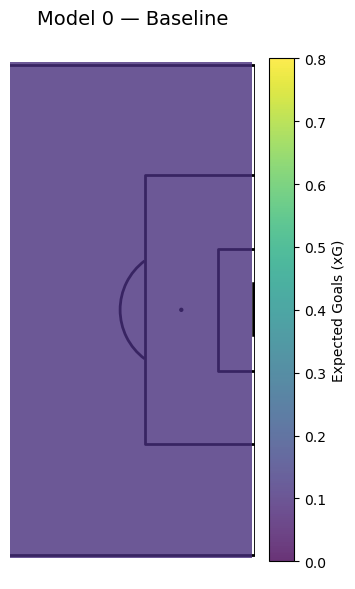

In [22]:
fig, ax = plot_xg_surface(
    predict_baseline_xg,
    title="Model 0 — Baseline",
    save_path="../../reports/figures/xg_surfaces/model_0_baseline.png"
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Calibration — Model 0 — Baseline'}, xlabel='Predicted xG', ylabel='Observed Goal Rate'>)

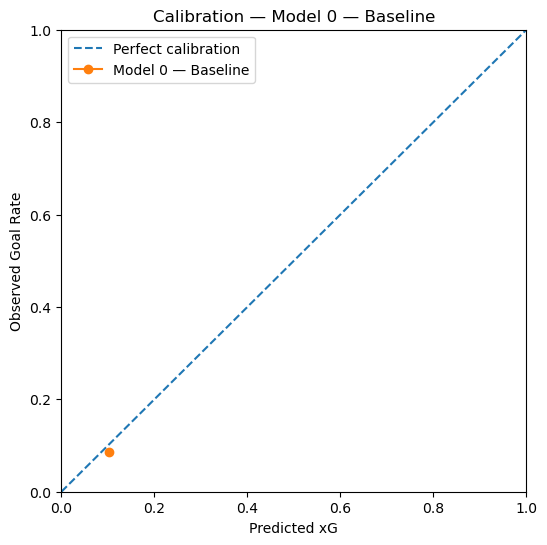

In [23]:
plot_calibration(
    y_test,
    test["xg_baseline"],
    model_name="Model 0 — Baseline",
    save_path="../../reports/figures/calibration/model_0_calibration.png"
)